# ⚖️ Comparação de Sistemas — RoBERTa: Voto Majoritário × Dados Reais

**Eixo 3** da pesquisa. Avalia o **impacto prático** de treinar o RoBERTa com
rótulos gerados automaticamente (consenso) versus com o *ground truth*.

A comparação é feita por **intervalos de confiança (IC 95%)** — abordagem de
comparação de sistemas (Jain), **sem testes de hipótese**. Dois passos:

1. **IC individual de cada sistema** (por dataset) — a média de F1 entre folds
   com seu IC95.
2. **IC da diferença pareada** `diff = real − majoritário` (folds correspondem ao
   mesmo *cross-validation*):
   - IC da diferença **contém 0** ⇒ sistemas **equivalentes** (95%);
   - IC **todo acima de 0** ⇒ **dados reais** melhores;
   - IC **todo abaixo de 0** ⇒ **majoritário** melhor.

Comparamos o **F1 macro por fold** de:

- **Majoritário** — RoBERTa treinado com consenso por **voto majoritário**.
  Fonte: `…/finetuning/roberta-base/roberta-base_fine_tuning_results.json`.
- **Real** — RoBERTa treinado com **rótulos verdadeiros**. Fonte:
  `data/results/mq/Roberta - Catizani.xlsx`, aba `effect-fold` (`mac0…mac9`).

**Datasets:** AGNews, MovieReview, DBLP, Books.

> Só o **F1 macro** existe nos dois lados. Convenção: `diff = real − majoritário`
> (positivo ⇒ dados reais melhores).


## 1) Setup e configuração

In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

ROOT = Path.cwd()
while not (ROOT / "data" / "results").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

CONF = 0.95   # nível de confiança

MAJ_FOLDER = {
    "agnews":       "agnews/2026-04-09_13-20-16 - rep1",
    "movie_review": "movie_review/2026-04-09_13-17-23",
    "dblp":         "dblp/2026-04-09_14-05-21",
    "books":        "books/2026-04-09_13-21-37",
}
DATASETS = list(MAJ_FOLDER)
RESULTS_DIR = ROOT / "data" / "results"
XLSX_REAL = RESULTS_DIR / "mq" / "Roberta - Catizani.xlsx"
FT_REL = "finetuning/roberta-base/roberta-base_fine_tuning_results.json"
print("Raiz do projeto:", ROOT)

Raiz do projeto: C:\Users\gabri\Documents\GitHub\llm-annotation


## 2) Carregar os folds dos dois sistemas

- **Majoritário**: `folds[i].eval_f1_macro` do JSON (ordenado pelo índice do fold).
- **Real**: `mac0…mac9` da linha do dataset na aba `effect-fold`.

Pareamos por **índice de fold** (mesmo split de CV). Quando o número de folds
difere (ex.: AGNews tem 5), usamos os folds em comum.

In [2]:
def load_majority_f1(dataset):
    path = RESULTS_DIR / MAJ_FOLDER[dataset] / FT_REL
    d = json.load(open(path, encoding="utf-8"))
    items = sorted((int(k), v["eval_f1_macro"]) for k, v in d["folds"].items())
    return [v for _, v in items]


def load_real_f1(dataset, df_real):
    row = df_real.loc[df_real["dataset"] == dataset].iloc[0]
    maccols = [f"mac{i}" for i in range(10)]
    return [float(row[c]) for c in maccols if pd.notna(row[c])]


df_real_sheet = pd.read_excel(XLSX_REAL, sheet_name="effect-fold")

records = []
for ds in DATASETS:
    maj = load_majority_f1(ds)
    real = load_real_f1(ds, df_real_sheet)
    n = min(len(maj), len(real))
    if len(maj) != len(real):
        print(f"⚠️  {ds}: nº de folds difere (maj={len(maj)}, real={len(real)}) → usando {n}")
    for i in range(n):
        records.append({"dataset": ds, "fold": i,
                        "f1_majoritario": maj[i], "f1_real": real[i]})

df_pairs = pd.DataFrame(records)
df_pairs["diff_real_maj"] = df_pairs["f1_real"] - df_pairs["f1_majoritario"]
print("Linhas (dataset × fold):", len(df_pairs))
df_pairs

Linhas (dataset × fold): 35


,dataset,fold,f1_majoritario,f1_real,diff_real_maj
0,agnews,0,0.8744,0.9187,0.0443
1,agnews,1,0.8669,0.9178,0.0510
2,agnews,2,0.8750,0.9159,0.0409
3,agnews,3,0.8679,0.9193,0.0514
4,agnews,4,0.8726,0.9149,0.0423
5,movie_review,0,0.8950,0.8913,-0.0038
6,movie_review,1,0.8941,0.8856,-0.0084
7,movie_review,2,0.8855,0.9006,0.0150
8,movie_review,3,0.8824,0.8949,0.0126
9,movie_review,4,0.8836,0.8883,0.0047


## 3) Função de intervalo de confiança

IC da média a 95% via *t* de Student:
$\bar{x} \pm t_{1-\alpha/2;\,n-1}\cdot s/\sqrt{n}$.

In [3]:
def mean_ci(x, conf=CONF):
    """Média e IC (low, high) via t de Student."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    m = x.mean()
    if n < 2:
        return m, np.nan, np.nan
    se = stats.sem(x)
    h = se * stats.t.ppf((1 + conf) / 2, n - 1)
    return m, m - h, m + h

## 4) Intervalos de confiança **individuais** (por sistema)

Para cada dataset, o IC95 da média de F1 macro entre folds — **separadamente**
para cada sistema (majoritário e real), antes de qualquer comparação.

In [4]:
ind_rows = []
for ds in DATASETS:
    sub = df_pairs[df_pairs["dataset"] == ds]
    for sistema, col in [("Majoritário", "f1_majoritario"),
                         ("Real (ground truth)", "f1_real")]:
        m, lo, hi = mean_ci(sub[col])
        ind_rows.append({
            "dataset": ds, "sistema": sistema, "n_folds": len(sub),
            "f1_media": m, "IC_low": lo, "IC_high": hi, "amplitude_IC": hi - lo,
        })

ic_individual = pd.DataFrame(ind_rows)
ic_individual

,dataset,sistema,n_folds,f1_media,IC_low,IC_high,amplitude_IC
0,agnews,Majoritário,5,0.8714,0.8667,0.8760,0.0093
1,agnews,Real (ground truth),5,0.9173,0.9150,0.9196,0.0047
2,movie_review,Majoritário,10,0.8878,0.8831,0.8926,0.0096
3,movie_review,Real (ground truth),10,0.8904,0.8837,0.8971,0.0134
4,dblp,Majoritário,10,0.6139,0.6068,0.6210,0.0142
5,dblp,Real (ground truth),10,0.8144,0.8092,0.8197,0.0105
6,books,Majoritário,10,0.7280,0.7223,0.7337,0.0114
7,books,Real (ground truth),10,0.8721,0.8663,0.8778,0.0115


### Gráfico — IC individual por sistema e dataset

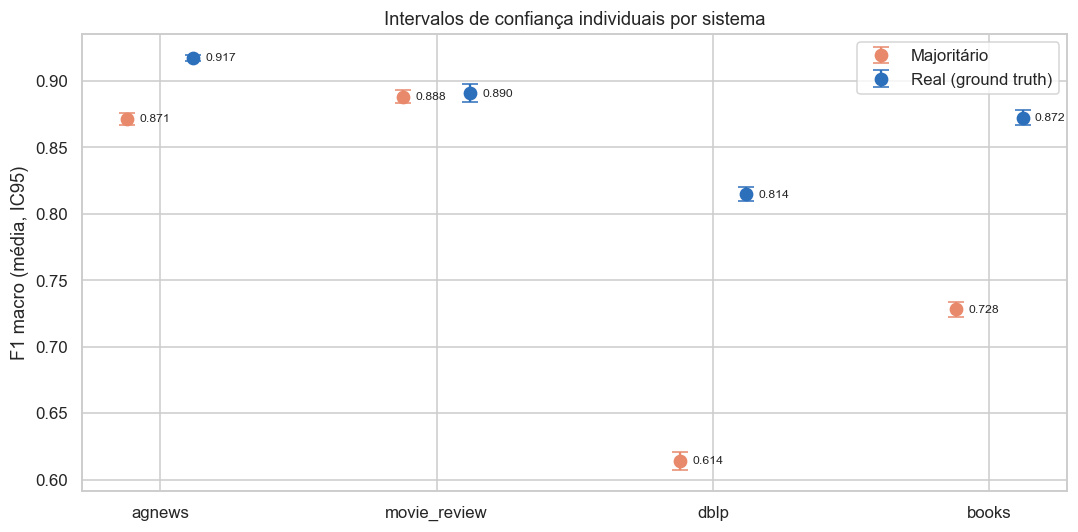

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
offset = {"Majoritário": -0.12, "Real (ground truth)": +0.12}
cores = {"Majoritário": "#e8896c", "Real (ground truth)": "#2c6fbb"}
for sistema in offset:
    d = ic_individual[ic_individual["sistema"] == sistema]
    xs = np.arange(len(DATASETS)) + offset[sistema]
    yerr = [d["f1_media"].values - d["IC_low"].values,
            d["IC_high"].values - d["f1_media"].values]
    ax.errorbar(xs, d["f1_media"], yerr=yerr, fmt="o", capsize=5, ms=8,
                color=cores[sistema], label=sistema)
    for x, m in zip(xs, d["f1_media"]):
        ax.annotate(f"{m:.3f}", (x, m), textcoords="offset points", xytext=(8, 0),
                    fontsize=8, va="center")
ax.set_xticks(np.arange(len(DATASETS))); ax.set_xticklabels(DATASETS)
ax.set_ylabel("F1 macro (média, IC95)")
ax.set_title("Intervalos de confiança individuais por sistema")
ax.legend(); plt.tight_layout(); plt.show()

## 5) Intervalo de confiança da **diferença pareada**

`diff = real − majoritário` por fold. O IC95 da diferença média decide a
comparação: **contém 0 ⇒ sistemas equivalentes**.

In [6]:
def conclusao(lo, hi):
    if lo <= 0 <= hi:
        return "equivalentes (IC contém 0)"
    return "Real melhor" if lo > 0 else "Majoritário melhor"


rows = []
for ds in DATASETS:
    sub = df_pairs[df_pairs["dataset"] == ds]
    mj = ic_individual.query("dataset == @ds and sistema.str.startswith('Maj')", engine="python")["f1_media"].iloc[0]
    rl = ic_individual.query("dataset == @ds and sistema.str.startswith('Real')", engine="python")["f1_media"].iloc[0]
    dm, d_lo, d_hi = mean_ci(sub["diff_real_maj"])
    rows.append({
        "dataset": ds, "n_folds": len(sub),
        "f1_maj_media": mj, "f1_real_media": rl,
        "diff_media": dm, "diff_IC_low": d_lo, "diff_IC_high": d_hi,
        "conclusao (95%)": conclusao(d_lo, d_hi),
    })

ic_diff = pd.DataFrame(rows)
ic_diff

,dataset,n_folds,f1_maj_media,f1_real_media,diff_media,diff_IC_low,diff_IC_high,conclusao (95%)
0,agnews,5,0.8714,0.9173,0.0460,0.0399,0.0521,Real melhor
1,movie_review,10,0.8878,0.8904,0.0026,-0.0047,0.0099,equivalentes (IC contém 0)
2,dblp,10,0.6139,0.8144,0.2006,0.1927,0.2084,Real melhor
3,books,10,0.7280,0.8721,0.1441,0.1361,0.1520,Real melhor


## 6) Gráficos da comparação pareada

C:\Users\gabri\AppData\Local\Temp\ipykernel_33116\773044038.py:15: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  ax.legend(); plt.tight_layout(); plt.show()
C:\Users\gabri\Documents\GitHub\llm-annotation\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


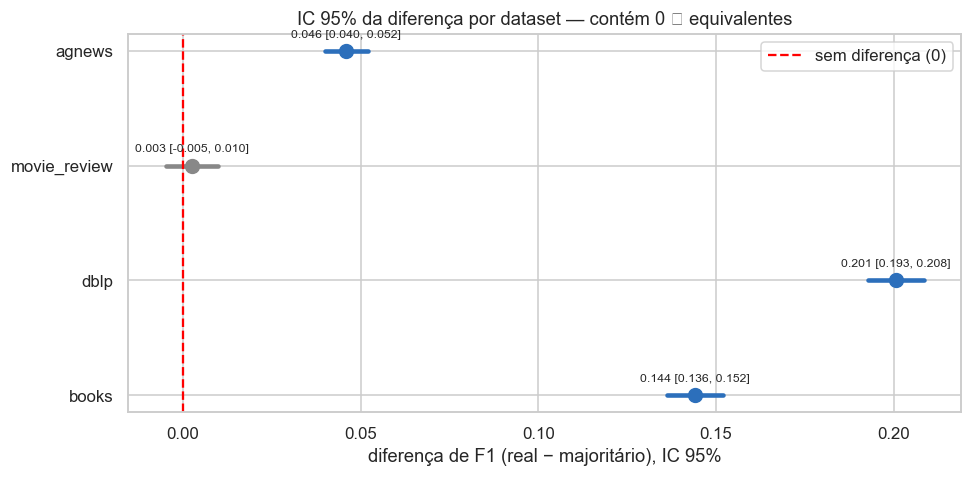

In [7]:
# Forest plot: IC95 da diferença (real - majoritário) por dataset
fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(ic_diff))[::-1]
for yi, (_, r) in zip(y, ic_diff.iterrows()):
    cor = "#2c6fbb" if r["diff_IC_low"] > 0 else ("#d1495b" if r["diff_IC_high"] < 0 else "#888")
    ax.plot([r["diff_IC_low"], r["diff_IC_high"]], [yi, yi], "-", color=cor, lw=3)
    ax.plot(r["diff_media"], yi, "o", color=cor, ms=9)
    ax.annotate(f"{r['diff_media']:.3f} [{r['diff_IC_low']:.3f}, {r['diff_IC_high']:.3f}]",
                (r["diff_media"], yi), textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=8)
ax.axvline(0, color="red", ls="--", label="sem diferença (0)")
ax.set_yticks(y); ax.set_yticklabels(ic_diff["dataset"])
ax.set_xlabel("diferença de F1 (real − majoritário), IC 95%")
ax.set_title("IC 95% da diferença por dataset — contém 0 ⇒ equivalentes")
ax.legend(); plt.tight_layout(); plt.show()

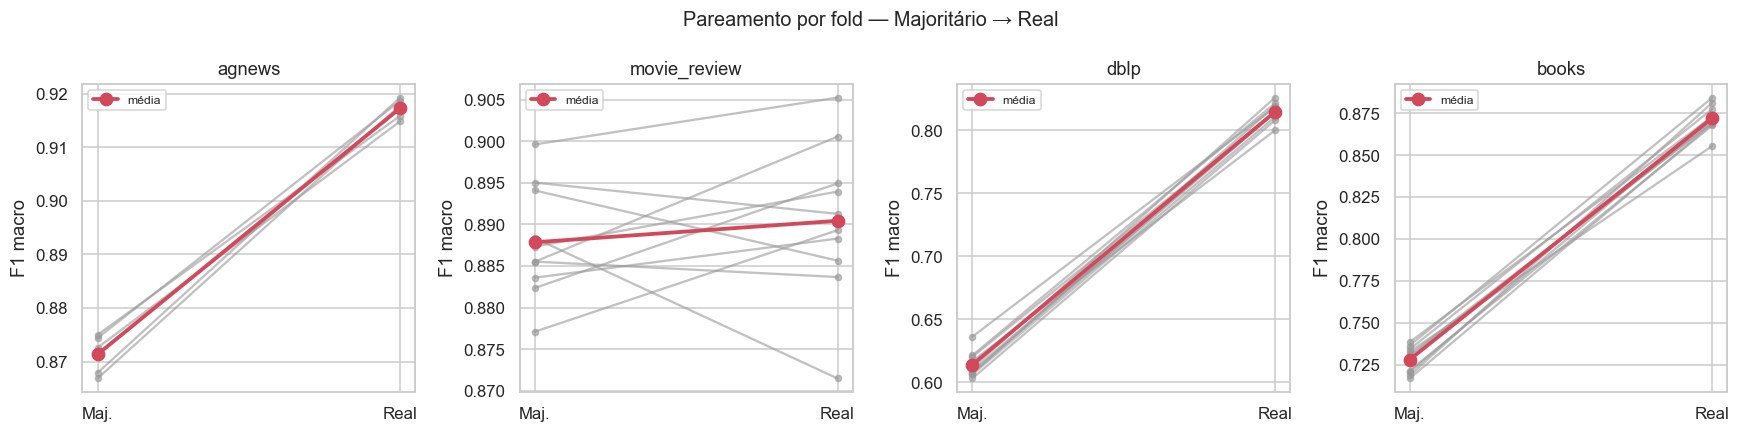

In [8]:
# Linhas pareadas por fold (majoritário → real) — small multiples
fig, axes = plt.subplots(1, len(DATASETS), figsize=(16, 4))
for ax, ds in zip(axes, DATASETS):
    sub = df_pairs[df_pairs["dataset"] == ds]
    for _, r in sub.iterrows():
        ax.plot([0, 1], [r["f1_majoritario"], r["f1_real"]], "-o", color="#999", alpha=0.6, ms=4)
    ax.plot([0, 1], [sub["f1_majoritario"].mean(), sub["f1_real"].mean()],
            "-o", color="#d1495b", lw=2.5, ms=8, label="média")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Maj.", "Real"])
    ax.set_title(ds); ax.set_ylabel("F1 macro"); ax.legend(fontsize=8)
fig.suptitle("Pareamento por fold — Majoritário → Real", fontsize=13)
plt.tight_layout(); plt.show()

## 7) IC agregado da diferença (todos os folds)

In [9]:
dm, d_lo, d_hi = mean_ci(df_pairs["diff_real_maj"])
print(f"N pares = {len(df_pairs)}")
print(f"diff média (real − majoritário) = {dm:.4f}")
print(f"IC 95% = [{d_lo:.4f}, {d_hi:.4f}]  ->  {conclusao(d_lo, d_hi)}")

N pares = 35
diff média (real − majoritário) = 0.1058
IC 95% = [0.0774, 0.1341]  ->  Real melhor


## 8) Conclusão

- **§4** dá o IC individual de cada sistema; **§5** dá o IC da diferença pareada,
  que decide a comparação.
- IC da diferença **contendo 0** ⇒ **equivalentes**: o consenso por maioria é
  suficiente para o *downstream* (anotar automaticamente sai quase de graça).
- Caso contrário, o sinal indica o vencedor e a magnitude (quanto se perde ao
  treinar com rótulos do consenso em vez do *ground truth*).


In [10]:
print("=== IC INDIVIDUAIS (por sistema) ===")
print(ic_individual.to_string(index=False))
print("\n=== IC DA DIFERENÇA PAREADA (real − majoritário) ===")
print(ic_diff.to_string(index=False))

=== IC INDIVIDUAIS (por sistema) ===
     dataset             sistema  n_folds  f1_media  IC_low  IC_high  amplitude_IC
      agnews         Majoritário        5    0.8714  0.8667   0.8760        0.0093
      agnews Real (ground truth)        5    0.9173  0.9150   0.9196        0.0047
movie_review         Majoritário       10    0.8878  0.8831   0.8926        0.0096
movie_review Real (ground truth)       10    0.8904  0.8837   0.8971        0.0134
        dblp         Majoritário       10    0.6139  0.6068   0.6210        0.0142
        dblp Real (ground truth)       10    0.8144  0.8092   0.8197        0.0105
       books         Majoritário       10    0.7280  0.7223   0.7337        0.0114
       books Real (ground truth)       10    0.8721  0.8663   0.8778        0.0115

=== IC DA DIFERENÇA PAREADA (real − majoritário) ===
     dataset  n_folds  f1_maj_media  f1_real_media  diff_media  diff_IC_low  diff_IC_high            conclusao (95%)
      agnews        5        0.8714         0

## 9) Exportar análise (.json) — `data/results/mq/comparacao_sistemas`

In [11]:
EXPORT_DIR = ROOT / "data" / "results" / "mq" / "comparacao_sistemas"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


def _jsonable(o):
    if isinstance(o, pd.DataFrame):
        return o.to_dict(orient="records")
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return float(o)
    if isinstance(o, (np.bool_,)):
        return bool(o)
    if isinstance(o, dict):
        return {k: _jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_jsonable(v) for v in o]
    return o


payload = {
    "descricao": "Comparação RoBERTa (IC 95%): voto majoritário (2x1) vs dados reais — F1 macro por fold",
    "nivel_confianca": CONF,
    "fontes": {
        "majoritario": {ds: MAJ_FOLDER[ds] + "/" + FT_REL for ds in DATASETS},
        "real": "data/results/mq/Roberta - Catizani.xlsx (aba effect-fold)",
    },
    "convencao_diff": "real - majoritario (positivo => dados reais melhores)",
    "por_fold": _jsonable(df_pairs),
    "ic_individual": _jsonable(ic_individual),
    "ic_diferenca_pareada": _jsonable(ic_diff),
    "agregado": {
        "n_pares": int(len(df_pairs)),
        "diff_media": float(dm), "diff_IC_low": float(d_lo), "diff_IC_high": float(d_hi),
        "conclusao": conclusao(d_lo, d_hi),
    },
}

with open(EXPORT_DIR / "comparacao_sistemas.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)
df_pairs.to_csv(EXPORT_DIR / "folds_por_sistema.csv", index=False)

print("✓ Salvo em:", EXPORT_DIR)
for p in sorted(EXPORT_DIR.glob("*")):
    print("  -", p.name)

✓ Salvo em: C:\Users\gabri\Documents\GitHub\llm-annotation\data\results\mq\comparacao_sistemas
  - comparacao_sistemas.json
  - folds_por_sistema.csv
